In [1]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('Datasets/AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 16)

In [4]:
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [5]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [7]:
df.drop(columns=['last_review','id','host_id'],inplace=True)

In [8]:
df.neighbourhood_group.nunique()

5

In [9]:
#df.drop(columns=['name'],inplace=True)
df.drop(columns=['host_name'],inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            48879 non-null  object 
 1   neighbourhood_group             48895 non-null  object 
 2   neighbourhood                   48895 non-null  object 
 3   latitude                        48895 non-null  float64
 4   longitude                       48895 non-null  float64
 5   room_type                       48895 non-null  object 
 6   price                           48895 non-null  int64  
 7   minimum_nights                  48895 non-null  int64  
 8   number_of_reviews               48895 non-null  int64  
 9   reviews_per_month               38843 non-null  float64
 10  calculated_host_listings_count  48895 non-null  int64  
 11  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(

In [11]:
df.isnull().sum()

name                                 16
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

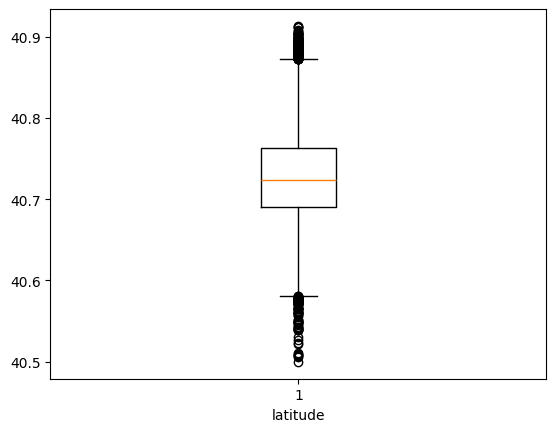

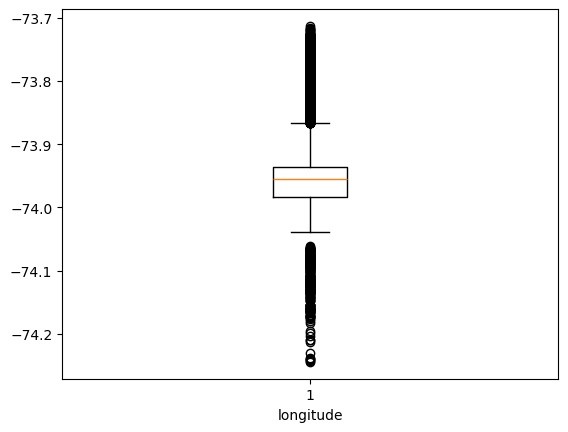

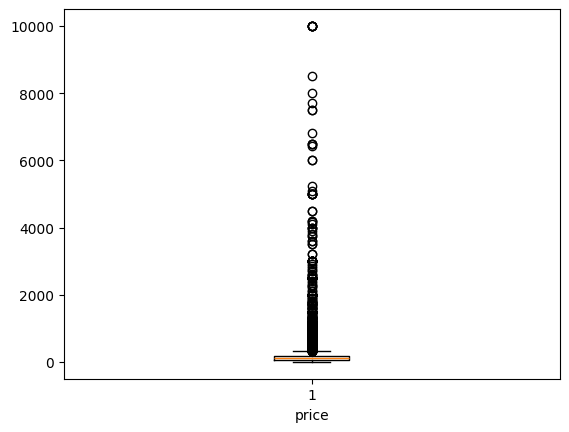

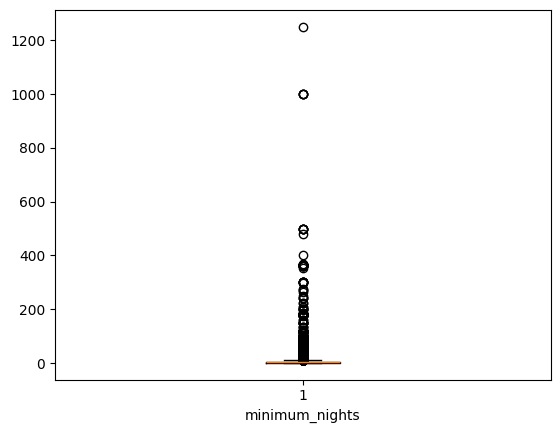

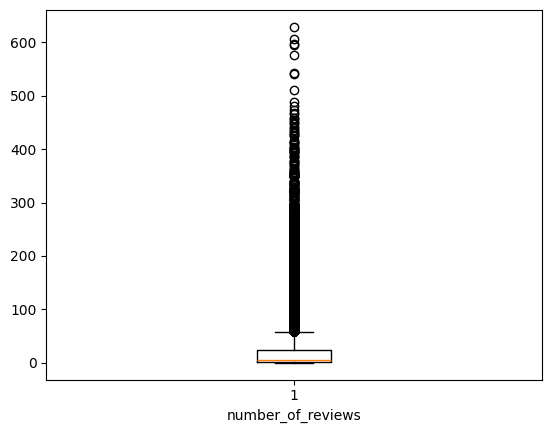

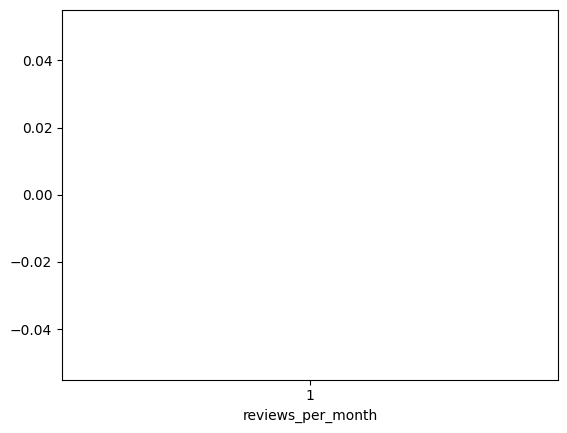

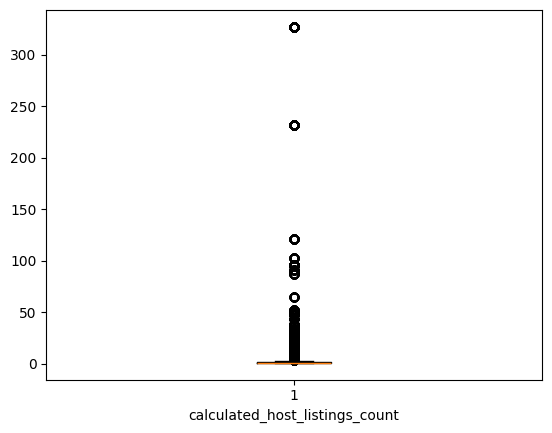

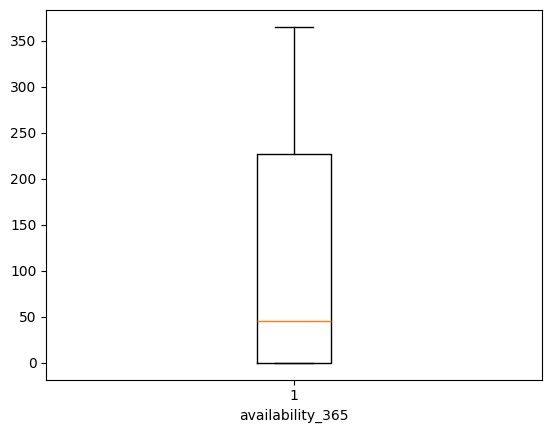

In [12]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        plt.boxplot(df[col])
        plt.xlabel(f'{col}')
        plt.show()

In [14]:
def drop_outliers(col,df=df):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    df=df[(df[col]>=q1-1.5*iqr)&(df[col]<=q3+1.5*iqr)]
    plt.boxplot(df[col])
    plt.xlabel(f'{col}')
    plt.show()
    return df

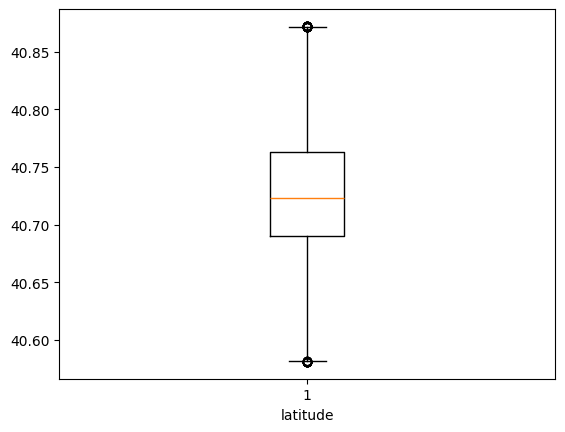

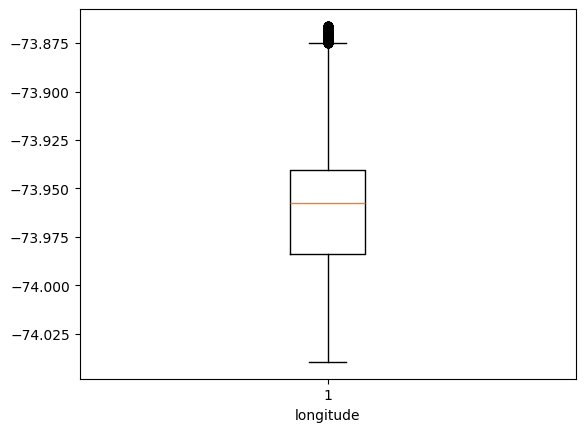

In [15]:
df=drop_outliers('latitude')
df=drop_outliers('longitude')

In [16]:
import numpy as np
df['price_log']=np.log(df['price'])
df.head()

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\user\AppData\Local\Temp\ipykernel_16332\2747831630.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_log']=np.log(df['price'])


,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_log
0,Clean & quiet apt home by the park,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.003946
1,Skylit Midtown Castle,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.416100
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365,5.010635
3,Cozy Entire Floor of Brownstone,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.488636
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.382027


In [17]:
df = df[df['price'] != 0]

In [18]:
df.price_log.describe()

count    46051.000000
mean         4.749662
std          0.695909
min          2.302585
25%          4.248495
50%          4.700480
75%          5.192957
max          9.210340
Name: price_log, dtype: float64

<Axes: ylabel='Frequency'>

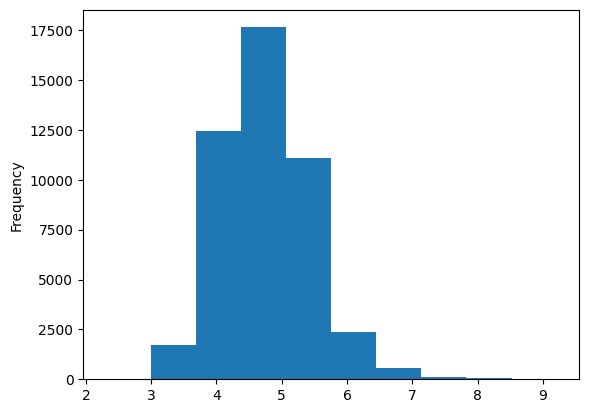

In [19]:
df.price_log.plot(kind='hist')

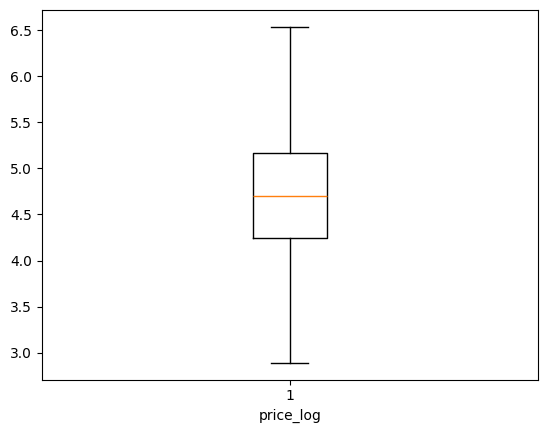

<Axes: ylabel='Frequency'>

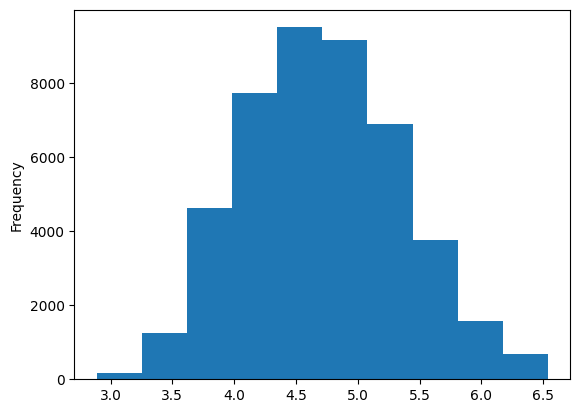

In [23]:
df=drop_outliers('price_log',df)
df.price_log.plot(kind='hist')

In [24]:
df.shape

(45364, 13)

In [25]:
df.isnull().sum()

name                                16
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                 9290
calculated_host_listings_count       0
availability_365                     0
price_log                            0
dtype: int64

In [26]:
df.drop(columns=['name','neighbourhood'],inplace=True)

In [27]:
df['reviews_per_month'].mean()

np.float64(1.3192593003271051)

In [28]:
df['reviews_per_month'].fillna(df['reviews_per_month'].mean(),inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_16332\2682408717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(df['reviews_per_month'].mean(),inplace=True)


In [29]:
df.dtypes

neighbourhood_group                object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
price_log                         float64
dtype: object

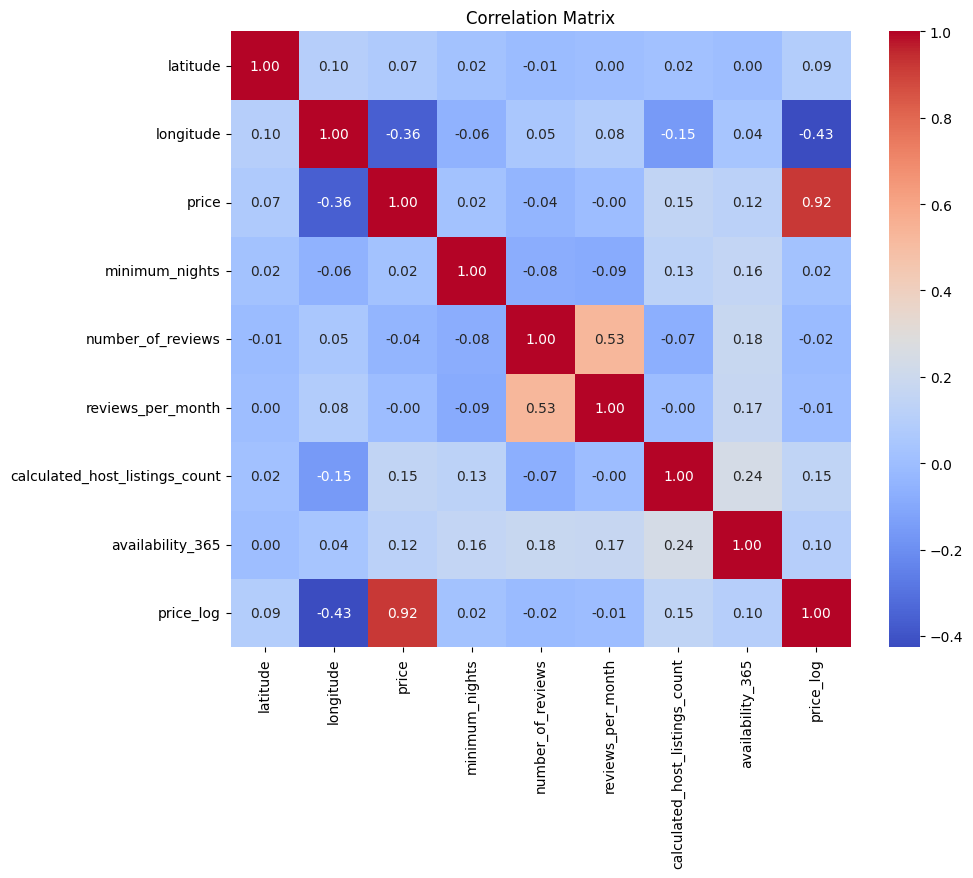

In [30]:
import seaborn as sns
corr=df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [31]:
# Automatically encode all object-type (categorical) columns
df_enc = pd.get_dummies(df, drop_first=True)
df_enc=df_enc.astype(int)
df_enc

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_log,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,room_type_Private room,room_type_Shared room
0,40,-73,149,1,9,0,6,365,5,1,0,0,1,0
1,40,-73,225,1,45,0,2,355,5,0,1,0,0,0
2,40,-73,150,3,0,1,1,365,5,0,1,0,1,0
3,40,-73,89,1,270,4,1,194,4,1,0,0,0,0
4,40,-73,80,10,9,0,1,0,4,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,40,-73,70,2,0,1,2,9,4,1,0,0,1,0
48891,40,-73,40,4,0,1,2,36,3,1,0,0,1,0
48892,40,-73,115,10,0,1,1,27,4,0,1,0,0,0
48893,40,-73,55,1,0,1,6,2,4,0,1,0,0,1


In [32]:
df_enc.drop(columns=['minimum_nights','number_of_reviews','reviews_per_month'],inplace=True)

In [33]:
df_enc.describe()

,latitude,longitude,price,calculated_host_listings_count,availability_365,price_log,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,room_type_Private room,room_type_Shared room
count,45364.0,45364.000000,45364.000000,45364.000000,45364.000000,45364.000000,45364.000000,45364.000000,45364.000000,45364.000000,45364.000000
mean,40.0,-73.068270,137.756238,7.377215,107.462658,4.243585,0.439556,0.465876,0.078895,0.453664,0.022992
std,0.0,0.252211,97.273705,33.838858,129.794348,0.710635,0.496338,0.498840,0.269578,0.497854,0.149879
min,40.0,-74.000000,18.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.0,-73.000000,70.000000,1.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,40.0,-73.000000,110.000000,1.000000,35.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,40.0,-73.000000,175.000000,2.000000,214.000000,5.000000,1.000000,1.000000,0.000000,1.000000,0.000000
max,40.0,-73.000000,690.000000,327.000000,365.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [34]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Prepare your data
X = df_enc.drop(columns=['price','price_log'])
y = df_enc['price_log']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=4)

# Fit LassoCV
lasso_cv = LassoCV(cv=7, random_state=42)
lasso_cv.fit(X_train, y_train)

# Best alpha found
Best_alpha= lasso_cv.alpha_

# Selected features
selected_features = X.columns[lasso_cv.coef_ != 0]
print("Selected features:", selected_features.tolist())


Selected features: ['longitude', 'calculated_host_listings_count', 'availability_365', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'room_type_Private room', 'room_type_Shared room']


In [35]:
from sklearn.linear_model import Lasso
model=Lasso(alpha=Best_alpha,max_iter=100,tol=0.1)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
model.score(X_test,y_test)

0.41712088739570763

In [36]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))


R²: 0.41712088739570763
MAE: 0.43873842896340487
RMSE: 0.29538333705359443


In [52]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
model.score(X_test,y_test)

0.3922607261982396

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn import svm

In [54]:
from sklearn.neighbors import KNeighborsRegressor
Knn=KNeighborsRegressor()

In [55]:
model_params={
    'random_forest':{
        'model':RandomForestRegressor(),
        'params':{
            'n_estimators':[10,30,50,70,90,120]
        }
    },
    'knn':{
        'model':KNeighborsRegressor(weights='uniform'),
        'params':{
            'n_neighbors':[1,4,5,6,7,8,9,10]
        }
    }
}

In [ ]:
scores=[]
for model,attr in model_params.items():
    clf=GridSearchCV(estimator=attr['model'],param_grid=attr['params'],cv=5)
    clf.fit(X_scaled,y)
    scores.append({
        'model':model,
        'best_score':clf.best_score_,
        'best_params':clf.best_params_
    })

In [ ]:
df_score=pd.DataFrame(scores,columns=['model','best_score','best_param'])
df_score